# Assignment 9: Using a Variational Autoencoder for Compression and Denoising

**Name**: Ashif Hussain

**Course**: BCA (AI/ML), Alliance University

**Faculty**: Sanjivini Chowdhury

**Reg No**: 2411021240056

In [1]:
# STEP 1: IMPORT LIBRARIES AND LOAD MNIST

# numpy: works with numbers and arrays
import numpy as np
# pandas: makes tables (we use it for the results table)
import pandas as pd
# matplotlib: draws images and graphs
import matplotlib.pyplot as plt
# tensorflow: the main library to build the model
import tensorflow as tf
# keras: makes building models easy
from tensorflow import keras
# layers: the building blocks of the model
from tensorflow.keras import layers

# Load MNIST: 70,000 handwritten digit pictures (0 to 9)
# x = the pictures, y = the digit labels
# train = 60,000 images for learning, test = 10,000 new images for checking
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Pixel values are 0 to 255. Change them to 0 to 1 so the model learns easily.
x_train = x_train.astype("float32") / 255.0
# Do the same for the test images
x_test = x_test.astype("float32") / 255.0

# Add a channel dimension: (28, 28) becomes (28, 28, 1). Keras needs this.
x_train = np.expand_dims(x_train, -1)
# Do the same for the test images
x_test = np.expand_dims(x_test, -1)

# Print the shapes to check that everything loaded correctly
print("Train:", x_train.shape, "Test:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (60000, 28, 28, 1) Test: (10000, 28, 28, 1)


In [2]:
# STEP 2: BUILD THE ENCODER AND DECODER

# Sampling layer: picks a random point near the mean
class Sampling(layers.Layer):
    # call runs every time data passes through this layer
    def call(self, inputs):
        # inputs are the mean and the log variance from the encoder
        z_mean, z_log_var = inputs
        # make random noise with the same shape as z_mean
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        # new point = mean + spread * noise
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# Function that builds an encoder. latent_dim = how many numbers we keep (2, 16 or 32)
def build_encoder(latent_dim):
    # input: a 28x28 image with 1 channel
    inp = keras.Input(shape=(28, 28, 1))
    # first conv layer: finds simple shapes, makes the image smaller (28 -> 14)
    x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(inp)
    # second conv layer: finds bigger shapes, makes the image smaller (14 -> 7)
    x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
    # flatten: turns the 7x7x64 block into one long list of numbers
    x = layers.Flatten()(x)
    # dense layer: mixes the numbers (same as Assignment 8)
    x = layers.Dense(16, activation="relu")(x)
    # z_mean: the centre point of the image in latent space
    z_mean = layers.Dense(latent_dim, name="z_mean")(x)
    # z_log_var: how much spread around the centre point
    z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
    # z: the random point picked using mean and log variance
    z = Sampling()([z_mean, z_log_var])
    # join everything into one encoder model
    return keras.Model(inp, [z_mean, z_log_var, z], name=f"encoder_{latent_dim}")

# Function that builds a decoder. It turns latent numbers back into an image
def build_decoder(latent_dim):
    # input: the latent numbers (2, 16 or 32 of them)
    inp = keras.Input(shape=(latent_dim,))
    # dense layer: expands the numbers into 7*7*64 values
    x = layers.Dense(7 * 7 * 64, activation="relu")(inp)
    # reshape: makes those values into a 7x7 block with 64 channels
    x = layers.Reshape((7, 7, 64))(x)
    # transpose conv: makes the picture bigger (7 -> 14)
    x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
    # transpose conv: makes the picture bigger again (14 -> 28)
    x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
    # last layer: makes 1 channel image, sigmoid keeps every pixel between 0 and 1
    out = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)
    # join everything into one decoder model
    return keras.Model(inp, out, name=f"decoder_{latent_dim}")

# Print a message so we know this cell worked
print("Encoder and decoder functions are ready")

Encoder and decoder functions are ready


In [3]:
# STEP 3: BUILD THE VAE CLASS WITH THE LOSS

# VAE class: joins the encoder and decoder and knows how to train them
class VAE(keras.Model):
    # __init__ runs once when we create the VAE
    def __init__(self, encoder, decoder, **kwargs):
        # set up the parent Keras model
        super().__init__(**kwargs)
        # save the encoder inside the VAE
        self.encoder = encoder
        # save the decoder inside the VAE
        self.decoder = decoder
        # tracker that remembers the total loss
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        # tracker that remembers the reconstruction loss
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        # tracker that remembers the KL loss
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    # tell Keras which numbers to show during training
    @property
    def metrics(self):
        # return the three trackers
        return [self.total_loss_tracker,
                self.reconstruction_loss_tracker,
                self.kl_loss_tracker]

    # train_step runs once for every batch of images
    def train_step(self, data):
        # GradientTape records the maths so Keras can learn from it
        with tf.GradientTape() as tape:
            # encode the image into mean, log variance and a random point z
            z_mean, z_log_var, z = self.encoder(data)
            # decode z back into an image
            reconstruction = self.decoder(z)

            # reconstruction loss: how different the new image is from the original
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(data, reconstruction),
                    axis=(1, 2)
                )
            )

            # KL loss: keeps the latent space close to a bell curve shape
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            # add up over the latent numbers, then average over the batch
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))

            # total loss = reconstruction loss + KL loss
            total_loss = reconstruction_loss + kl_loss

        # find how to change the weights to reduce the loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        # change the weights a little bit
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        # save the loss values for this batch
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        # return the loss values so Keras can print them
        return {
            "total_loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

# Print a message so we know this cell worked
print("VAE class is ready")

VAE class is ready


In [4]:
# STEP 4: TRAIN THREE VAEs (latent size 2, 16 and 32)

# the three latent sizes we want to test
latent_sizes = [2, 16, 32]

# dictionaries to save the encoder and decoder of each size
encoders = {}
decoders = {}

# repeat the same training for each latent size
for d in latent_sizes:
    # print which size is training now
    print(f"\n===== Training VAE with latent_dim = {d} =====")
    # build a new encoder and decoder for this size
    enc = build_encoder(d)
    dec = build_decoder(d)
    # join them into one VAE
    m = VAE(enc, dec)
    # get the VAE ready, Adam is the optimizer that updates the weights
    m.compile(optimizer=keras.optimizers.Adam())
    # train for 20 epochs (20 full passes over 60,000 images), same as Assignment 8
    m.fit(x_train, epochs=20, batch_size=128, verbose=2)
    # save the trained encoder and decoder
    encoders[d] = enc
    decoders[d] = dec

# Print a message so we know training finished
print("\nAll VAEs trained")


===== Training VAE with latent_dim = 2 =====
Epoch 1/20
469/469 - 18s - 39ms/step - kl_loss: 1.5441 - reconstruction_loss: 215.7752 - total_loss: 217.3195
Epoch 2/20
469/469 - 3s - 7ms/step - kl_loss: 2.7620 - reconstruction_loss: 182.1593 - total_loss: 184.9213
Epoch 3/20
469/469 - 3s - 6ms/step - kl_loss: 4.6863 - reconstruction_loss: 162.8507 - total_loss: 167.5370
Epoch 4/20
469/469 - 3s - 6ms/step - kl_loss: 5.0638 - reconstruction_loss: 157.6528 - total_loss: 162.7165
Epoch 5/20
469/469 - 3s - 6ms/step - kl_loss: 5.2551 - reconstruction_loss: 155.2570 - total_loss: 160.5121
Epoch 6/20
469/469 - 3s - 7ms/step - kl_loss: 5.3709 - reconstruction_loss: 153.7390 - total_loss: 159.1100
Epoch 7/20
469/469 - 3s - 6ms/step - kl_loss: 5.4487 - reconstruction_loss: 152.6338 - total_loss: 158.0825
Epoch 8/20
469/469 - 3s - 6ms/step - kl_loss: 5.5364 - reconstruction_loss: 151.5803 - total_loss: 157.1167
Epoch 9/20
469/469 - 3s - 6ms/step - kl_loss: 5.5958 - reconstruction_loss: 150.8892 - t

In [5]:
# STEP 5: PART A - COMPRESSION RATIO

# original image size: 28 x 28 = 784 values
original_size = 28 * 28

# do the same calculation for each latent size
for d in latent_sizes:
    # compression ratio = original size / latent size
    ratio = original_size / d
    # print the result: 784 values become d values
    print(f"latent {d:>2}: {original_size} values -> {d} values, ratio = {ratio:.1f}:1")

latent  2: 784 values -> 2 values, ratio = 392.0:1
latent 16: 784 values -> 16 values, ratio = 49.0:1
latent 32: 784 values -> 32 values, ratio = 24.5:1


latent 2: average MSE = 0.04057
   MSE of each image: [0.0164, 0.0729, 0.0036, 0.031, 0.0354, 0.0054, 0.0547, 0.0532, 0.0997, 0.0333]


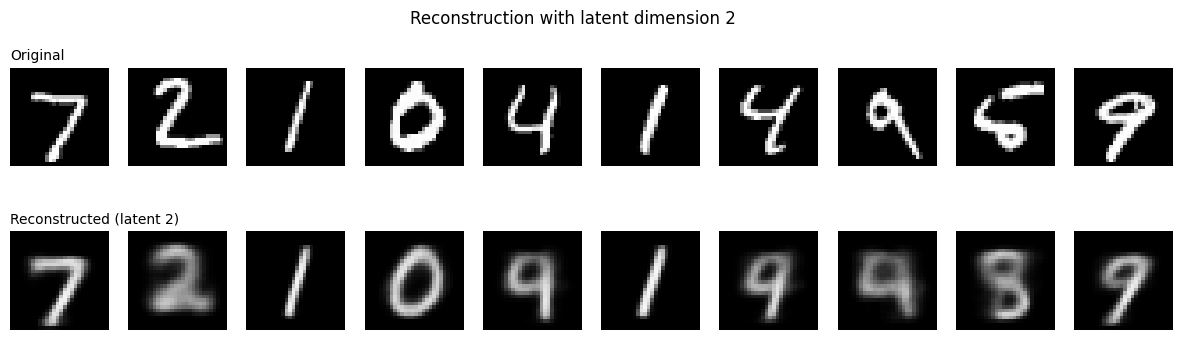

latent 16: average MSE = 0.03739
   MSE of each image: [0.016, 0.0702, 0.0027, 0.0302, 0.0303, 0.0039, 0.0625, 0.0371, 0.0968, 0.0243]


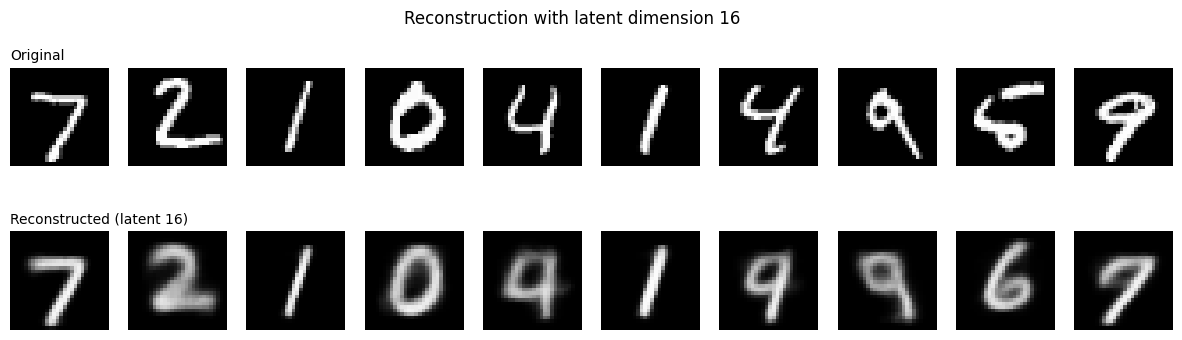

latent 32: average MSE = 0.02600
   MSE of each image: [0.0128, 0.0383, 0.002, 0.0251, 0.0228, 0.0024, 0.0434, 0.0288, 0.0644, 0.02]


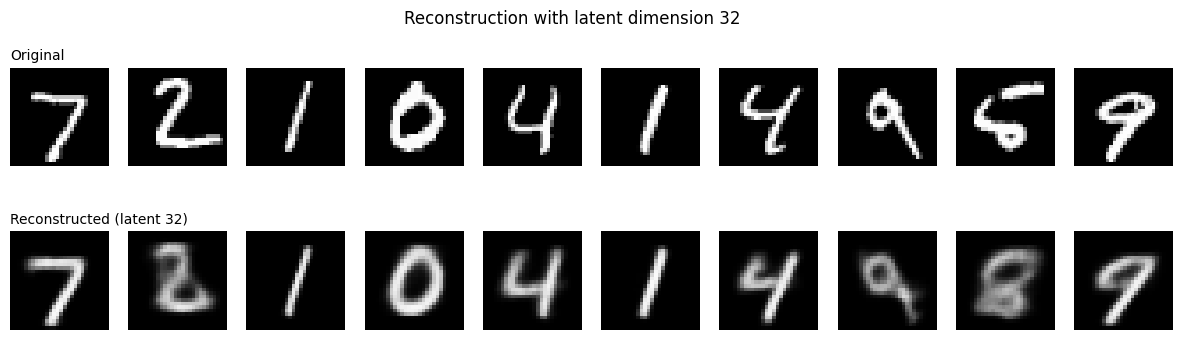

In [6]:
# STEP 6: PART B - RECONSTRUCTION AND MSE

# take the first 10 test images
imgs = x_test[:10]

# function: encode images, then decode them back
def reconstruct(d, images):
    # encode: use z_mean (the centre point) so the result is stable
    z_mean = encoders[d].predict(images, verbose=0)[0]
    # decode: turn the latent numbers back into images
    return decoders[d].predict(z_mean, verbose=0)

# function: Mean Squared Error = average of (a - b) squared
def mse(a, b):
    # lower MSE means the two images are more alike
    return float(np.mean((a - b) ** 2))

# function: draw rows of 10 images and save the picture as a file
def show_rows(rows, names, title, fname):
    # make a grid: one row for each set of images, 10 columns
    fig, axes = plt.subplots(len(rows), 10, figsize=(15, 1.7 * len(rows) + 0.5))
    # go through each row of images
    for r, row in enumerate(rows):
        # go through each of the 10 images in the row
        for i in range(10):
            # draw the image in grey colours (0 = black, 1 = white)
            axes[r, i].imshow(row[i].squeeze(), cmap="gray", vmin=0, vmax=1)
            # hide the axis numbers
            axes[r, i].axis("off")
        # write the row name above the first image
        axes[r, 0].set_title(names[r], loc="left", fontsize=10)
    # write the main title
    fig.suptitle(title)
    # save the picture as a file
    plt.savefig(fname, bbox_inches="tight", dpi=120)
    # show the picture on screen
    plt.show()

# dictionary to save the average MSE of each latent size
recon_mse = {}

# repeat for each latent size
for d in latent_sizes:
    # encode and decode the 10 images
    rec = reconstruct(d, imgs)
    # calculate the average MSE for all 10 images
    recon_mse[d] = mse(rec, imgs)
    # calculate the MSE of each single image
    per_image = [round(mse(rec[i], imgs[i]), 4) for i in range(10)]
    # print the average MSE
    print(f"latent {d}: average MSE = {recon_mse[d]:.5f}")
    # print the MSE of each image
    print("   MSE of each image:", per_image)
    # draw original (top row) and reconstructed (bottom row), and save as recon_d.png
    show_rows([imgs, rec], ["Original", f"Reconstructed (latent {d})"],
              f"Reconstruction with latent dimension {d}", f"recon_{d}.png")

latent 2: noisy MSE = 0.04552, denoised MSE = 0.07154


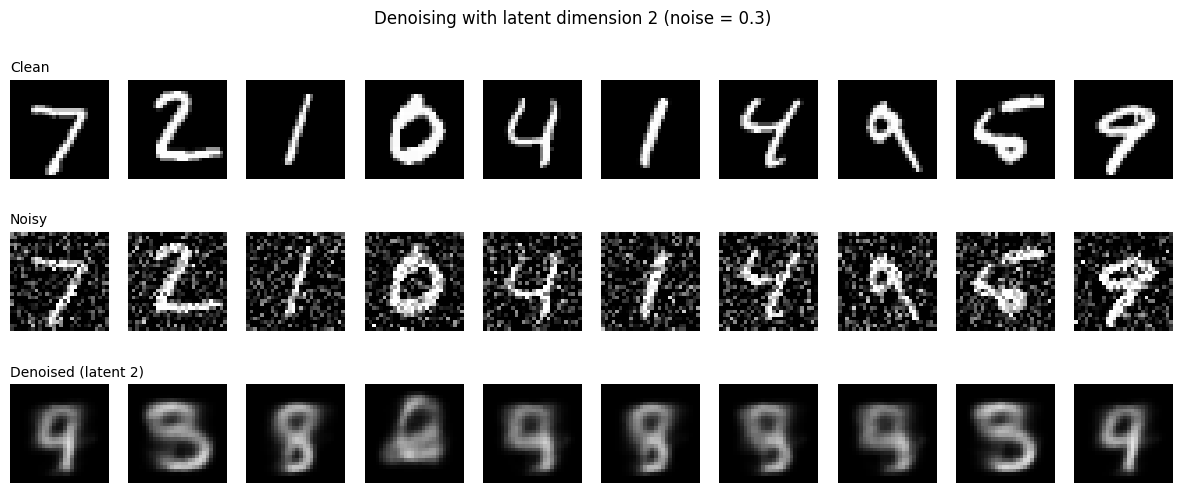

latent 16: noisy MSE = 0.04552, denoised MSE = 0.08634


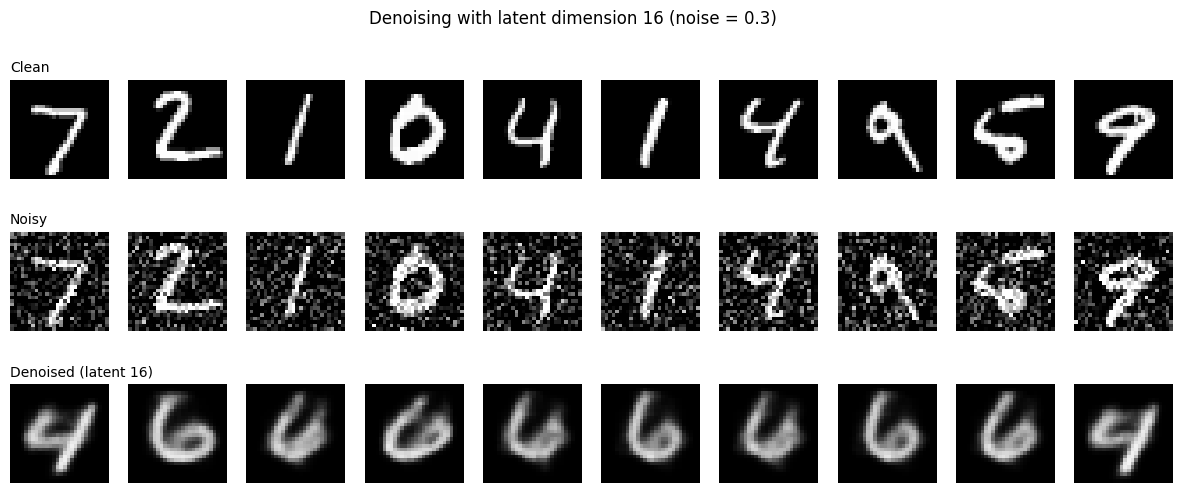

latent 32: noisy MSE = 0.04552, denoised MSE = 0.06993


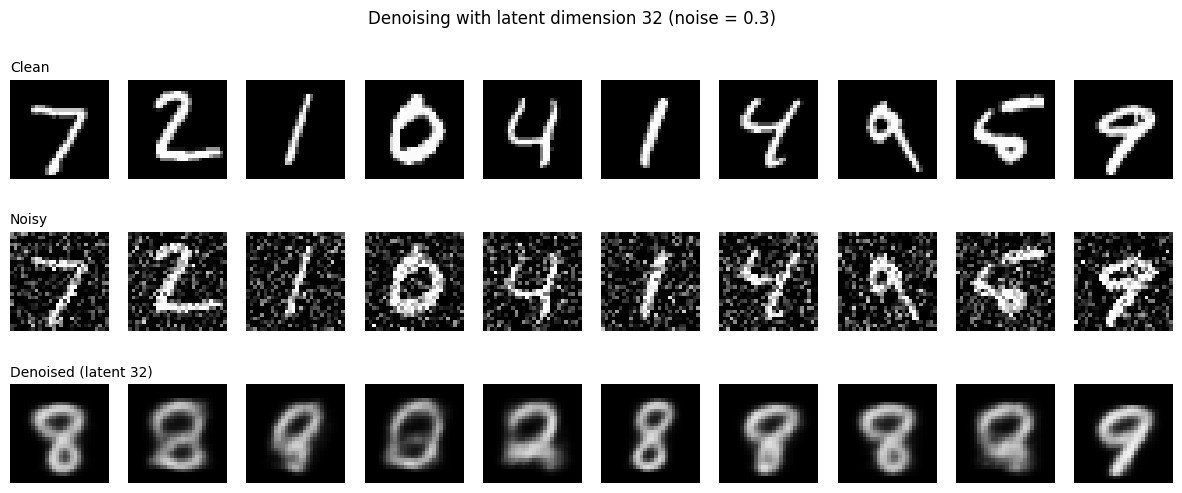

In [7]:
# STEP 7: PART C - DENOISING

# fix the random numbers so you get the same noise every time
np.random.seed(0)

# noise level: how strong the noise is (0.3 is medium)
noise_level = 0.3

# add Gaussian noise to the 10 images, then clip pixels to stay between 0 and 1
noisy = np.clip(imgs + noise_level * np.random.randn(*imgs.shape), 0, 1).astype("float32")

# MSE between the noisy images and the clean images
noisy_mse = mse(noisy, imgs)

# dictionary to save the denoised MSE of each latent size
denoise_mse = {}

# repeat for each latent size
for d in latent_sizes:
    # pass the noisy images through the VAE (encode, then decode)
    den = reconstruct(d, noisy)
    # MSE between the denoised images and the CLEAN images
    denoise_mse[d] = mse(den, imgs)
    # print noisy MSE and denoised MSE (lower is better)
    print(f"latent {d}: noisy MSE = {noisy_mse:.5f}, denoised MSE = {denoise_mse[d]:.5f}")
    # draw clean, noisy and denoised rows, and save as denoise_d.png
    show_rows([imgs, noisy, den], ["Clean", "Noisy", f"Denoised (latent {d})"],
              f"Denoising with latent dimension {d} (noise = {noise_level})", f"denoise_{d}.png")

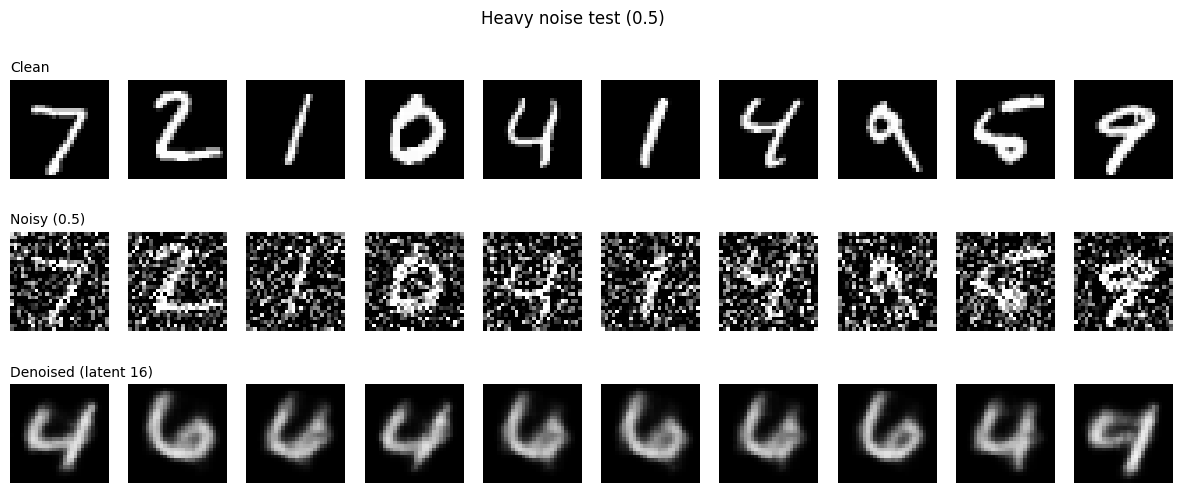

 Noise level  Noisy MSE  Denoised MSE (latent 2)  Denoised MSE (latent 16)  Denoised MSE (latent 32)
         0.2    0.02070                  0.06199                   0.07366                   0.06091
         0.3    0.04552                  0.07154                   0.08634                   0.06993
         0.5    0.11241                  0.07791                   0.09633                   0.08735


In [8]:
# STEP 8: EXTRA - TRY DIFFERENT NOISE LEVELS (0.2, 0.3, 0.5)

# list to save the results of each noise level
extra = []

# repeat for each noise level
for nl in [0.2, 0.3, 0.5]:
    # use the same seed so the noise is fair each time
    np.random.seed(0)
    # add noise of this level to the 10 images and clip to 0..1
    nz = np.clip(imgs + nl * np.random.randn(*imgs.shape), 0, 1).astype("float32")
    # start a table row with the noise level and the noisy MSE
    row = {"Noise level": nl, "Noisy MSE": round(mse(nz, imgs), 5)}
    # for each latent size, find the denoised MSE
    for d in latent_sizes:
        row[f"Denoised MSE (latent {d})"] = round(mse(reconstruct(d, nz), imgs), 5)
    # add this row to the list
    extra.append(row)
    # for the strongest noise, also draw the pictures
    if nl == 0.5:
        show_rows([imgs, nz, reconstruct(16, nz)],
                  ["Clean", "Noisy (0.5)", "Denoised (latent 16)"],
                  "Heavy noise test (0.5)", "denoise_noise05_latent16.png")

# turn the list into a table and print it
extra_df = pd.DataFrame(extra)
print(extra_df.to_string(index=False))

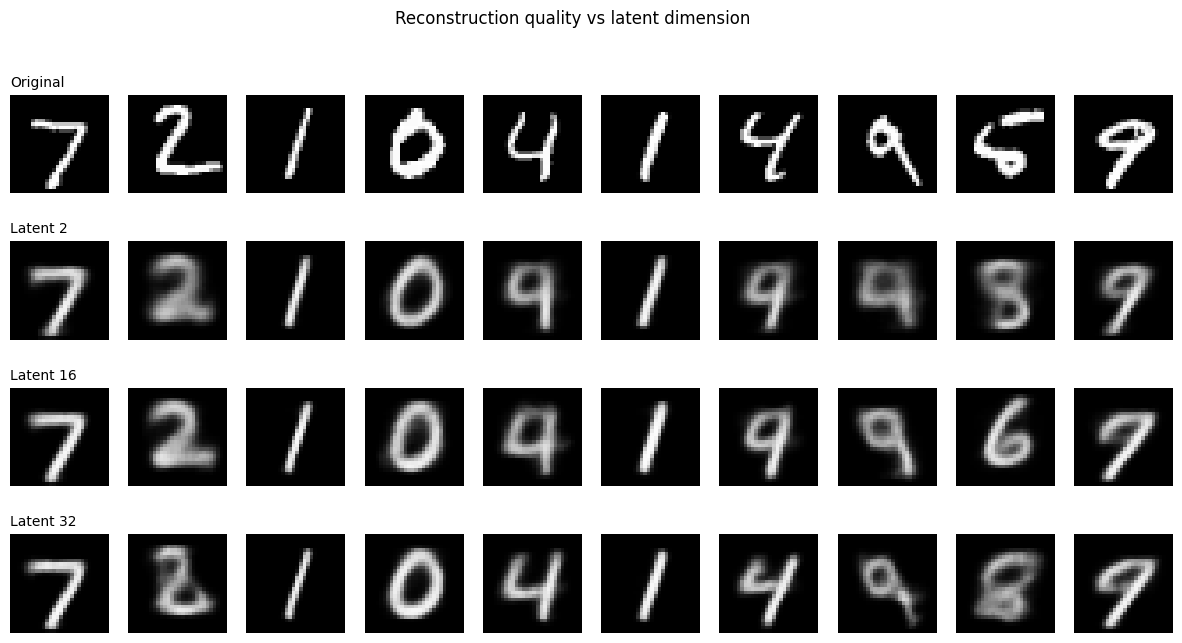

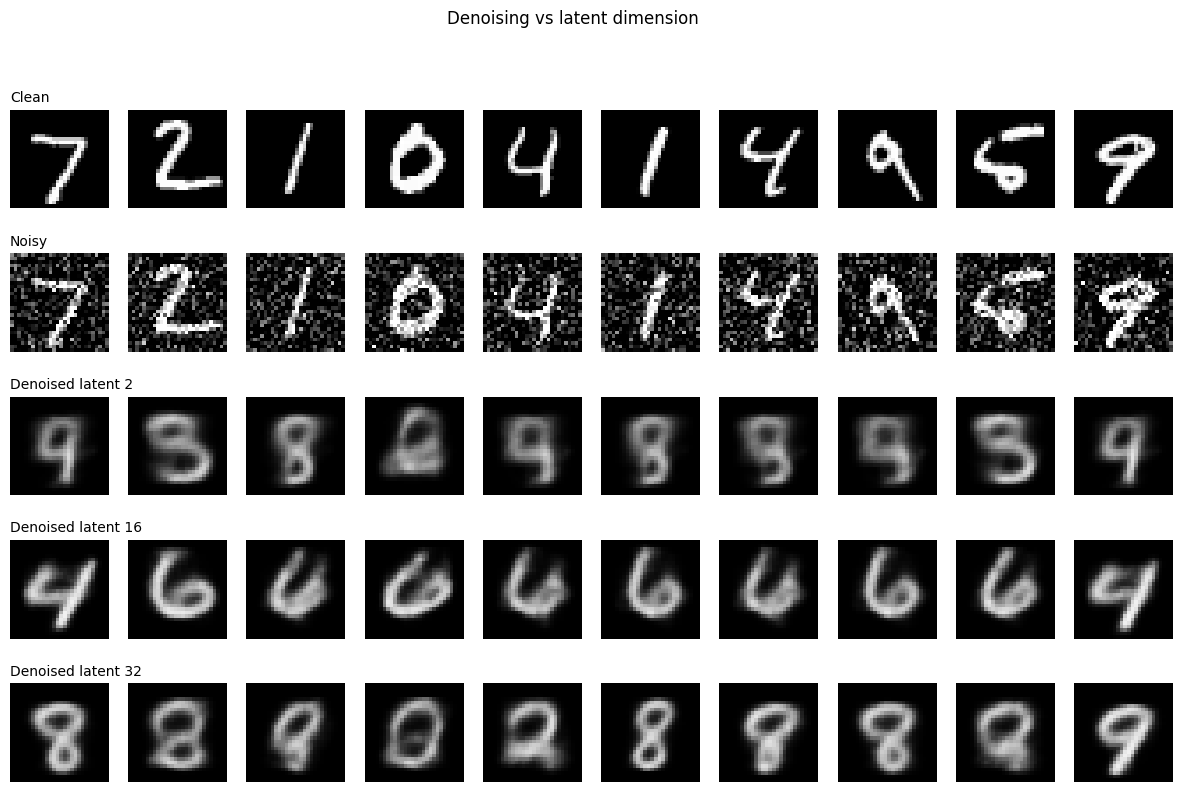

In [9]:
# STEP 9: PART D - COMPARE ALL LATENT SIZES SIDE BY SIDE

# rows for reconstruction: original, then reconstructed images from latent 2, 16, 32
rows = [imgs] + [reconstruct(d, imgs) for d in latent_sizes]
# draw all rows in one picture and save it as compare_all_latent.png
show_rows(rows, ["Original", "Latent 2", "Latent 16", "Latent 32"],
          "Reconstruction quality vs latent dimension", "compare_all_latent.png")

# rows for denoising: clean, noisy, then denoised images from latent 2, 16, 32
rows = [imgs, noisy] + [reconstruct(d, noisy) for d in latent_sizes]
# draw all rows in one picture and save it as compare_all_denoise.png
show_rows(rows, ["Clean", "Noisy", "Denoised latent 2", "Denoised latent 16", "Denoised latent 32"],
          "Denoising vs latent dimension", "compare_all_denoise.png")

In [10]:
# STEP 10: RESULTS TABLE

# build a table with one row for each latent size
df = pd.DataFrame({
    # the latent sizes: 2, 16, 32
    "Latent dim": latent_sizes,
    # compression ratio = 784 / latent size
    "Compression ratio": [f"{784/d:.1f}:1" for d in latent_sizes],
    # average reconstruction MSE from Step 6
    "Reconstruction MSE": [round(recon_mse[d], 5) for d in latent_sizes],
    # MSE of the noisy images (same for all rows)
    "Noisy MSE": [round(noisy_mse, 5)] * len(latent_sizes),
    # MSE of the denoised images from Step 7
    "Denoised MSE": [round(denoise_mse[d], 5) for d in latent_sizes],
})

# print the table
print(df.to_string(index=False))

# save the table as a file called results.csv
df.to_csv("results.csv", index=False)

 Latent dim Compression ratio  Reconstruction MSE  Noisy MSE  Denoised MSE
          2           392.0:1             0.04057    0.04552       0.07154
         16            49.0:1             0.03739    0.04552       0.08634
         32            24.5:1             0.02600    0.04552       0.06993


## Final Results Table

| Latent dim | Compression ratio | Reconstruction error (MSE) | Reconstruction quality | Denoising observations |
|---|---|---|---|---|
| 2 | 392:1 | 0.04057 | Poor. Blurry, and several digits are wrong (4 became 9, 5 became 8). | Denoised MSE 0.07154 is higher than noisy MSE 0.04552. Most digits became 9, 5 or 8. Noise is gone, but the digits are wrong. |
| 16 | 49:1 | 0.03739 | Better. Sharper, but some digits are still wrong (5 became 6, 9 became 7). | Denoised MSE 0.08634 is the highest. Most digits became 6 or 4. |
| 32 | 24.5:1 | 0.02600 | Best. Sharpest, but a few digits are still unclear (2 and 5 look like 8). | Denoised MSE 0.06993 is the lowest of the three, but still higher than noisy MSE. Many digits became 8. |

## Conclusion

1. A bigger latent size gives lower reconstruction error and sharper images. MSE went from 0.04057 (latent 2) to 0.02600 (latent 32).
2. A bigger latent size means less compression: 392:1 for latent 2, 49:1 for latent 16 and 24.5:1 for latent 32.
3. Latent 2 is too small. It made blurry images and changed some digits (for example 4 became 9 and 5 became 8).
4. Latent 16 and 32 keep more detail. Latent 32 has the lowest MSE, but a few digits (like 2 and 5) are still unclear.
5. Denoising did not work well at noise level 0.3. The denoised MSE (0.07 to 0.086) was higher than the noisy MSE (0.04552) for all three sizes.
6. The reason is that the VAE was trained only on clean images. The noisy image looks very different to the encoder, so it picks the wrong point in latent space and decodes a wrong digit. Many digits turned into 6 (latent 16) or 8 (latent 32).
7. Compression and quality are a trade-off. A small latent size gives high compression but poor quality. A large latent size gives better quality but less compression.
8. A better way to denoise is to train the VAE with noisy images as input and clean images as targets.